
# Supresvised Learning. Classification and Segmentation

**Name:** Kahla Maha




---



Topics: pytorch, data preparation, data augmentation, custom model, transfer learning, classification, segmentation

Основные задачи

1. Решить проблему **классификации** дорожных фотографий
  1. Подготовьте данные и решите проблему несбалансированного набора данных
  2. Реализуйте и обучите пользовательский классификатор
  3. Реализуйте конвейер проверки
  4. Добавьте дополнения к данным и сравните результаты
  5. Загрузка предварительно обученной модели и настройка для фотографий дорог

Main Tasks
1. Solve the road photo **classification** problem
  1. Prepare data and solve imbalanced dataset problem
  2. Implement and train a custom classifier
  3. Implement validation pipeline
  4. Add data augmentation and compare results
  5. Load pre-trained model and tune for road photos
  


 ## Enviroment setup

Import packages

In [ ]:
import numpy as np

import torch
from torch import nn
from torch.nn import functional as F
from torch import optim

from torchvision import models, transforms

import time
import math
import random

from torch.utils.data import TensorDataset, DataLoader, Dataset
from sklearn.metrics import accuracy_score

import seaborn as sns
from matplotlib import colors, pyplot as plt
from matplotlib import rcParams
from IPython.display import clear_output

from tqdm import tqdm

%matplotlib inline
rcParams['figure.figsize'] = (15,4)
sns.set(style="darkgrid", font_scale=1.4)

Define the device variable to run notebook on gpu if it is available and cpu in the opposite case without any notebook modifications

In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

GPU = torch.device('cuda:0')
CPU = torch.device('cpu')

Specify a seed to more reproducable results. Now the mentioned below random generators will produce the same random sequencies.

In [ ]:
SEED = 42 # You can set any interger here

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

Here some snippets to check GPU params

In [ ]:
!nvidia-smi
train_on_gpu = torch.cuda.is_available()

if not train_on_gpu:
    print('CUDA is not available.  Training on CPU ...')
else:
    print('CUDA is available!  Training on GPU ...')

Sat Apr  5 00:40:21 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

The snippet below can be used to check GPU memory allocation and clean it

In [ ]:
import gc
torch.cuda.empty_cache()
gc.collect()

#Additional Info when using cuda
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')

Tesla T4
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB


## Dataset loading

###  From personal Google drive


In [ ]:
from google.colab import drive
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [ ]:
!ls /content/gdrive/MyDrive

In [ ]:
!unzip -q /content/gdrive/MyDrive/segmentation.zip

## Data preparation

### Data checking

In [ ]:
X = np.load('./x_train.npy')
Y = np.load('./y_train.npy')

print(X.shape)
print(Y.shape)
# print(Y[0])

(3083, 256, 256, 3)
(3083, 256, 256, 1)


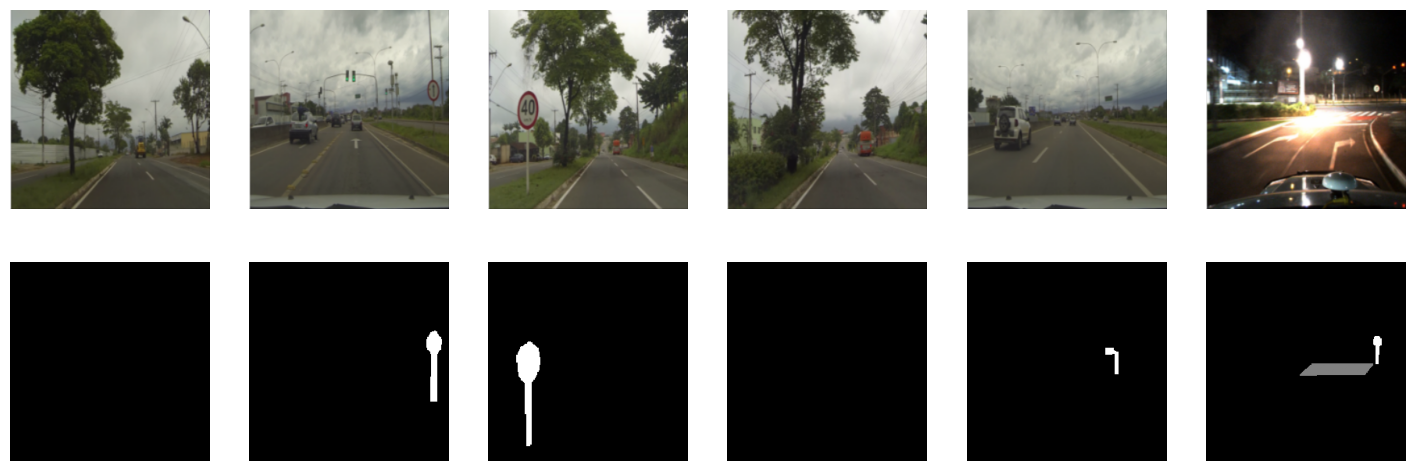

In [ ]:
plt.figure(figsize=(18, 6))
for i in range(6):
    j = 100+10*i;
    plt.subplot(2, 6, i+1)
    plt.axis("off")
    plt.imshow(X[j])

    plt.subplot(2, 6, i+7)
    plt.axis("off")
    plt.imshow(Y[j].squeeze(), cmap='gray')
plt.show();

### Preparing target values for the classification task

Let us find all possible Y values in the dataset

In [ ]:
unique, counts = np.unique(Y, return_counts=True)

result = np.column_stack((unique, counts))
print(result)

[[        0 192720674]
 [        1   8499283]
 [        2    827531]]


If number of non-black pixels is less than threshold, then we say that there is not a road sign on the photo

In [ ]:
sum_by_image = np.sum(Y, (1, 2, 3))
print(sum_by_image.shape)

(3083,)


In [ ]:
unique, counts = np.unique(sum_by_image, return_counts=True)
result = np.column_stack((unique, counts))
print (result)

[[    0   461]
 [    8     1]
 [   32     1]
 ...
 [29420     1]
 [29790     1]
 [33807     1]]


In [ ]:
threshold = 2000 # Define threshold for the number of non-black pixels
Y_c = np.array(sum_by_image > threshold, dtype='uint8')
print(Y_c.shape)

(3083,)


Now we have labels for classification task

In [ ]:
print(Y_c[0:100])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


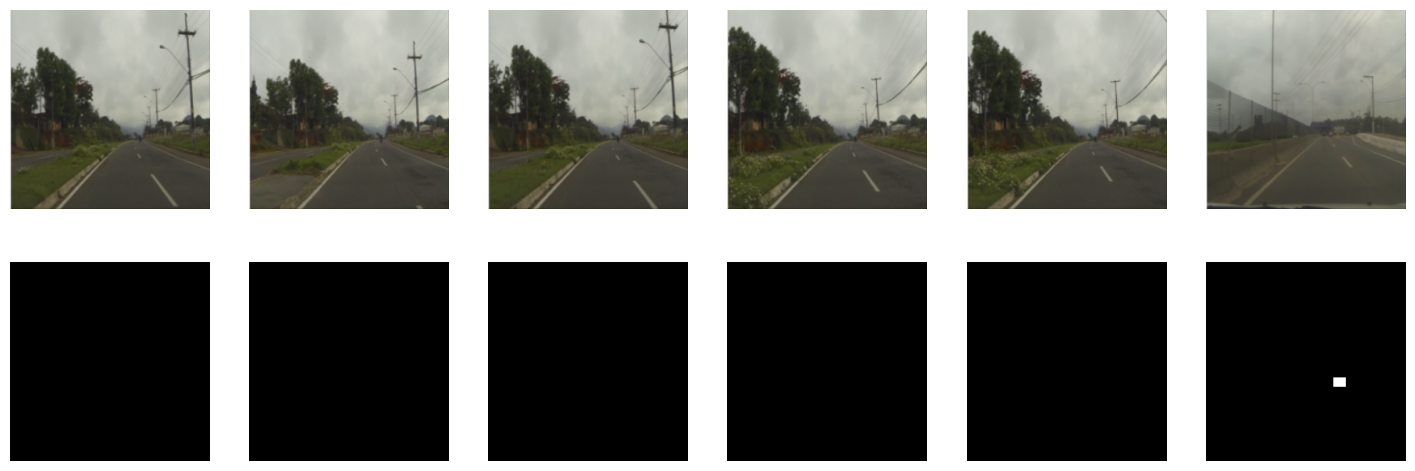

In [ ]:
plt.figure(figsize=(18, 6))
for i in range(6):
    j = 2 + i;
    plt.subplot(2, 6, i+1)
    plt.axis("off")
    plt.imshow(X[j])

    plt.subplot(2, 6, i+7)
    plt.axis("off")
    plt.imshow(Y[j].squeeze(), cmap='gray')
plt.show();

### Data normalization

For pytorch, the channel should be the second dimension, not the last one.

In [ ]:
X_r = np.transpose(X, axes=(0, 3, 1, 2))
Y_r = Y_c
print(X_r.shape, Y_r.shape)

(3083, 3, 256, 256) (3083,)


To calculate the mean and std, I created the TensorDataset first without normalization and ran the following code, then implemented the normalization with the results.

In [ ]:
# sumel = 0.0
# countel = 0
# for img, _ in train_dataset:
#     sumel += img.sum([1, 2])
#     countel += torch.numel(img[0])
# mean = sumel/countel
# print(mean)

tensor([0.3993, 0.4034, 0.4015])


In [ ]:
# sumel = 0.0
# countel = 0
# for img, _ in train_dataset:
#     img = (img - mean.unsqueeze(1).unsqueeze(1))**2
#     sumel += img.sum([1, 2])
#     countel += torch.numel(img[0])
# std = torch.sqrt(sumel/countel)
# print(std)

tensor([0.2326, 0.2318, 0.2521])


Normalize data and convert to tensors

In [ ]:
X_f = X_r/255 
X_t = torch.FloatTensor(X_f)

for x in X_t:
  transforms.functional.normalize (x, (0.3993, 0.4034, 0.4015), (0.2326, 0.2318, 0.2521), inplace=True) 

Y_t = torch.FloatTensor(Y_r)

Splitting dataset

Let us divide for traning, validation and test correspondingly.

In [ ]:
ix = np.random.choice(len(X_t), len(X_t), False)
val_index = 2500 
test_index = 2900 

tr, val, ts = np.split(ix, [val_index, test_index])

In [ ]:
X_train_t = X_t[tr]
X_val_t = X_t[val]
X_test_t = X_t[ts]

Y_train_t = Y_t[tr]
Y_val_t = Y_t[val]
Y_test_t = Y_t[ts]

train_dataset = TensorDataset(X_train_t, Y_train_t)
val_dataset = TensorDataset(X_val_t, Y_val_t)
test_dataset = TensorDataset(X_test_t, Y_test_t)

In [ ]:
X = 0
Y = 0
gc.collect()

0

In [ ]:
unique, counts = np.unique(Y_train_t, return_counts=True)
result = np.column_stack((unique, counts))
print (result)

[[0.000e+00 1.276e+03]
 [1.000e+00 1.224e+03]]


Check converted and normalized data

In [ ]:
def imshow(inp, title=None, plt_ax=plt, default=False):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = (0.3993, 0.4034, 0.4015) 
    std = (0.2326, 0.2318, 0.2521) 
    inp = inp*std + mean 
    inp = np.clip(inp, 0, 1)
    plt_ax.imshow(inp)
    if title is not None:
      if hasattr(plt_ax, 'set_title'):
        plt_ax.set_title(title)
      if hasattr(plt_ax, 'title'):
        plt_ax.title(title)
    plt_ax.grid(False)

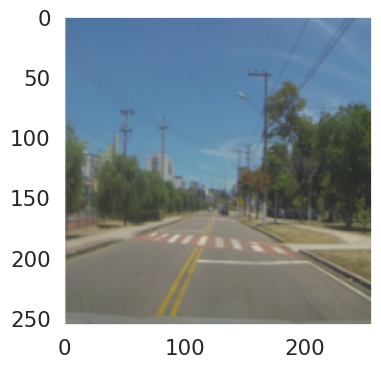

In [ ]:
imshow(X_train_t[0])

### Classes balancing and creating dataloaders

Let's count how many pictures we have for each class.

In [ ]:
unique, counts = np.unique(Y_r, return_counts=True)
result = np.column_stack((unique, counts))
print(result)

[[   0 1576]
 [   1 1507]]


We could not apply this because it seems to be balanced, but I did it anyway.

In order for the classes to be balanced in training, we calculate the weights and create a sampler.
For the validation and test, we will not use balancing.

In [ ]:
unique, counts = np.unique(Y_r[tr], return_counts=True)
w = [np.max(counts)/np.sum(counts) , np.min(counts)/np.sum(counts) ] 
print(w)

[np.float64(0.5104), np.float64(0.4896)]


In [ ]:
from torch.utils.data import WeightedRandomSampler

In [ ]:
weights = [w[0] if x == 0 else w[1] for x in Y_r[tr]]
sampler = WeightedRandomSampler(weights , len(weights)) 

print(Y_r[tr][50:100:5])
print(weights[50:100:5])

[0 0 0 0 1 1 0 0 0 0]
[np.float64(0.5104), np.float64(0.5104), np.float64(0.5104), np.float64(0.5104), np.float64(0.4896), np.float64(0.4896), np.float64(0.5104), np.float64(0.5104), np.float64(0.5104), np.float64(0.5104)]


In [ ]:
train_dataloader = DataLoader(train_dataset, batch_size=128, sampler=sampler)
val_dataloader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=False)

Let's check that the classes are balanced now

In [ ]:
YY_check = np.array([])

for _, y in train_dataloader:
  YY_check = np.hstack((YY_check, y.detach().numpy()))

unique, counts = np.unique(YY_check, return_counts=True)
result = np.column_stack((unique, counts))
print(result)

[[0.000e+00 1.297e+03]
 [1.000e+00 1.203e+03]]


Taking into account the imbalance of classes in the validation and test samples, we will use a special metric to evaluate the quality of training.

In [ ]:
from sklearn.metrics import balanced_accuracy_score

## Custom classifier and training

**Goal**: balanced_accuracy_score metric on the test part of the dataset is at least **0.95**.

In [ ]:
kernel_size = 3
stride = 1
padding = 1
n_classes = 2

In [ ]:
class SimpleCnn(nn.Module):

    def __init__(self, size, n_classes):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size, stride, padding),
            nn.ReLU(),
            nn.MaxPool2d (kernel_size = 2),
            nn.BatchNorm2d(16)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(16,32, kernel_size, stride, padding),
            nn.ReLU(),
            nn.MaxPool2d (kernel_size = 2),
            nn.BatchNorm2d(32)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size, stride, padding),
            nn.ReLU(),
            nn.MaxPool2d (kernel_size = 2),
            nn.BatchNorm2d(64)
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(64, 128 , kernel_size, stride, padding),
            nn.ReLU(),
            nn.MaxPool2d (kernel_size = 2),
            nn.BatchNorm2d(128)
        )


        fc_inputs = int((size/16)*(size/16)*128)

        self.out = nn.Sequential (
            nn.Flatten(),
            nn.Linear(fc_inputs , 96*5),
            nn.ReLU(),
            nn.BatchNorm1d(96*5),
            nn.Dropout(0.2),

            nn.Linear(96*5 , 96*4),
            nn.ReLU(),
            nn.BatchNorm1d(96*4),
            nn.Dropout(0.2),

            nn.Linear(96*4 , n_classes)
        )




    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)

        x = x.view(x.size(0), -1)
        logits = self.out(x)

        return logits.squeeze()

Let us define training function

In [ ]:
def train(model, optimizer, loss_function, dataloader, max_epochs = 10):
  losses = np.zeros(max_epochs)

  model.train()
  for epoch in range(max_epochs):
      for it, (X_batch, y_batch) in enumerate(dataloader):
          X_batch = X_batch.to(device)
          y_batch = y_batch.to(device)

          optimizer.zero_grad()

          outp = model(X_batch)  # predict y with model using X_batch

          loss = loss_function(outp.squeeze(), y_batch)
          losses[epoch] = losses[epoch] + loss.detach().flatten()[0]

          loss.backward() # call back propagation and gradient calculation
          optimizer.step() # call weights update

          y_batch = y_batch.cpu()
          X_batch = X_batch.cpu()
          outp = outp.cpu()

      print(f"Epoch {epoch}: loss={losses[epoch]}")

  return losses

Now we can create model, define loss function and optimizer

In [ ]:
simpleNN = SimpleCnn(256,1 ).to(device) # create model and move it to device
loss_function = nn.BCEWithLogitsLoss() #  create loss function
learning_rate = 0.001 
optimizer = torch.optim.Adam(simpleNN.parameters(), lr=learning_rate)

and train our model

In [ ]:
max_epochs = 50 
losses = train(simpleNN, optimizer, loss_function, train_dataloader, max_epochs)

Epoch 0: loss=9.788385391235352
Epoch 1: loss=8.401717185974121
Epoch 2: loss=7.836772918701172
Epoch 3: loss=7.724013805389404
Epoch 4: loss=7.333879470825195
Epoch 5: loss=7.068848609924316
Epoch 6: loss=6.893309593200684
Epoch 7: loss=6.914768218994141
Epoch 8: loss=6.8388519287109375
Epoch 9: loss=6.541256904602051
Epoch 10: loss=6.372262477874756
Epoch 11: loss=5.974525451660156
Epoch 12: loss=6.019636154174805
Epoch 13: loss=5.913731098175049
Epoch 14: loss=5.851086139678955
Epoch 15: loss=5.640439033508301
Epoch 16: loss=5.7563629150390625
Epoch 17: loss=5.584291458129883
Epoch 18: loss=5.646528244018555
Epoch 19: loss=5.473299026489258
Epoch 20: loss=5.426780700683594
Epoch 21: loss=5.202639102935791
Epoch 22: loss=5.197635650634766
Epoch 23: loss=5.1524248123168945
Epoch 24: loss=5.063316822052002
Epoch 25: loss=5.126453399658203
Epoch 26: loss=5.0357346534729
Epoch 27: loss=5.086119651794434
Epoch 28: loss=4.8368706703186035
Epoch 29: loss=5.099120140075684
Epoch 30: loss=5.0

In [ ]:
def plot_losses(losses):
  plt.figure(figsize=(12, 8))
  plt.plot(range(len(losses)), losses)
  plt.xlabel("Iteration")
  plt.ylabel("Loss")
  plt.show()

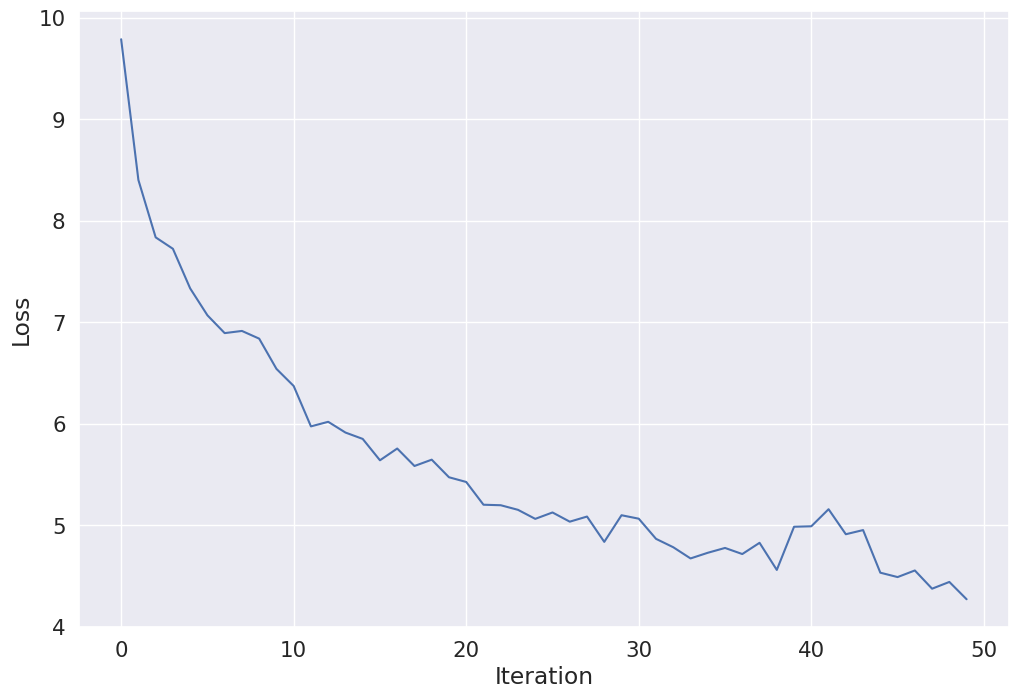

In [ ]:
plot_losses(losses)

We can additionally train the model with the lowel learning rate. However, the better idea is to use [schedulers](https://www.kaggle.com/code/isbhargav/guide-to-pytorch-learning-rate-scheduling), so we suggest to try it.

## Model validation

In order to check overfitting we compate metric results on the train and validation datasets. If everything is ok, then we check on test dataset.

In [ ]:
@torch.no_grad()
def predict(dataloader, model):
    model.eval()
    predictions = np.array([])
    y_target = np.array([])
    for x_batch, y_batch in dataloader:
        y_target = np.hstack((y_target, y_batch.numpy().flatten()))
        x_batch = x_batch.to(device)
        lgts = model(x_batch)
        probs = torch.sigmoid(lgts)
        preds = (probs > 0.5).type(torch.long).cpu()
        predictions = np.hstack((predictions, preds.numpy().flatten()))
        x_batch = x_batch.cpu()
    model.train()
    # We return also target for the cases, when data is shuffled
    return predictions.flatten(), y_target

In [ ]:
Y_pred_train, Y_target_train = predict(train_dataloader, simpleNN)
# calculate accuracy with balanced_accuracy_score function
accuracy = balanced_accuracy_score(Y_target_train, Y_pred_train)
print("Train accuracy:", accuracy)

Train accuracy: 0.9822458209902666


In [ ]:
Y_pred_val, Y_target_val = predict(val_dataloader, simpleNN)
# calculate accuracy with balanced_accuracy_score function
accuracy = balanced_accuracy_score(Y_target_val, Y_pred_val)
print("Validation accuracy:", accuracy)

Validation accuracy: 0.9158000364896917


In [ ]:
Y_test_pred, Y_test_target = predict(test_dataloader, simpleNN)
# calculate accuracy with balanced_accuracy_score function
accuracy = balanced_accuracy_score(Y_test_target, Y_test_pred)
print( "test accuracy:",accuracy)

test accuracy: 0.9407511940946591


we got an accuracy of 91.5% on the validation part of the dataset. It seems that the used model is good, we try to increase the accuracy using data augmentation or using a pretrained model.

**Goal:** balanced_accuracy_score metric on the val part of the dataset is at least 0.85. 

## Data Augmentation

In the common case the best way to increase size of the dataset is using on-fly data augmentation. In this case each time when we get item from the dataset transformation with random parameters is applied. However, the transformations must give you realistic images that are similar to the original images.

For the on-fly transformations we will create custom class dataset

In [ ]:
class OurOwnDataset(Dataset):
    def __init__(self, data, labels, transforms=None):
        self.data = data
        self.labels = labels
        self.transforms = transforms

        print(f'Found {len(self.data)} items')

    def __getitem__(self, i):
        image = self.data[i]

        if self.transforms:
            image = self.transforms(image)

        label = self.labels[i]

        return image, label

    def __len__(self):
        return len(self.df)

In [ ]:
from torchvision.transforms import Compose , RandomHorizontalFlip, RandomAdjustSharpness 

getitem_transforms = Compose([
  #  add transforms
  RandomHorizontalFlip(p=0.5),
  RandomAdjustSharpness(sharpness_factor=2)
])

train_dataset_augmented = OurOwnDataset(X_train_t, Y_train_t, transforms=getitem_transforms)

Found 2500 items


Check how it is working

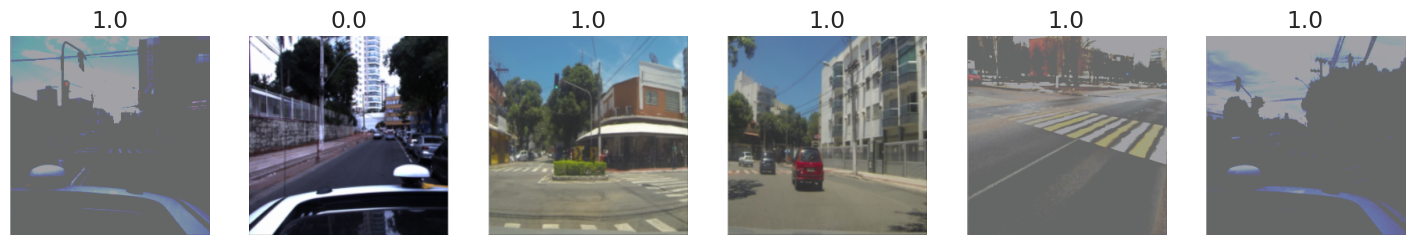

In [ ]:
plt.figure(figsize=(18, 6))
for i in range(6):
    j = 100+10*i;
    image, label = train_dataset_augmented.__getitem__(j)

    plt.subplot(2, 6, i+1)
    plt.axis("off")

    imshow(image, title=f'{label}', plt_ax=plt)
plt.show();

In [ ]:
train_dataloader_augmented = DataLoader(train_dataset_augmented, batch_size=128, sampler=sampler)

Now we can create new model and train it

In [ ]:
model2 = SimpleCnn(256 , 1).to(device) # create a new model with SimpleCnn class and move it to device
optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.005)
loss_function = nn.BCEWithLogitsLoss()
# learning_rate2 = # TODO: set learning rate
# optimizer = torch.optim.Adam(model2.parameters(), lr=learning_rate2)

In [ ]:
max_epochs = 50 
losses2 = train(model2 , optimizer2, loss_function, train_dataloader_augmented, max_epochs) #  call train function and pass train_dataloader_augmented as dataloader

Epoch 0: loss=13.118183135986328
Epoch 1: loss=10.753807067871094
Epoch 2: loss=8.858133316040039
Epoch 3: loss=7.96035623550415
Epoch 4: loss=6.433942794799805
Epoch 5: loss=5.822413921356201
Epoch 6: loss=4.380064964294434
Epoch 7: loss=4.053193092346191
Epoch 8: loss=3.9766178131103516
Epoch 9: loss=3.3264198303222656
Epoch 10: loss=3.4416868686676025
Epoch 11: loss=2.9708504676818848
Epoch 12: loss=2.8311164379119873
Epoch 13: loss=2.0221734046936035
Epoch 14: loss=2.0619444847106934
Epoch 15: loss=2.142524003982544
Epoch 16: loss=1.7290738821029663
Epoch 17: loss=1.6058858633041382
Epoch 18: loss=1.7499268054962158
Epoch 19: loss=1.4361990690231323
Epoch 20: loss=1.2823748588562012
Epoch 21: loss=1.313584804534912
Epoch 22: loss=1.3726556301116943
Epoch 23: loss=0.9596739411354065
Epoch 24: loss=1.1664278507232666
Epoch 25: loss=1.1359968185424805
Epoch 26: loss=1.2842538356781006
Epoch 27: loss=1.1232728958129883
Epoch 28: loss=0.9349586367607117
Epoch 29: loss=0.800613522529602


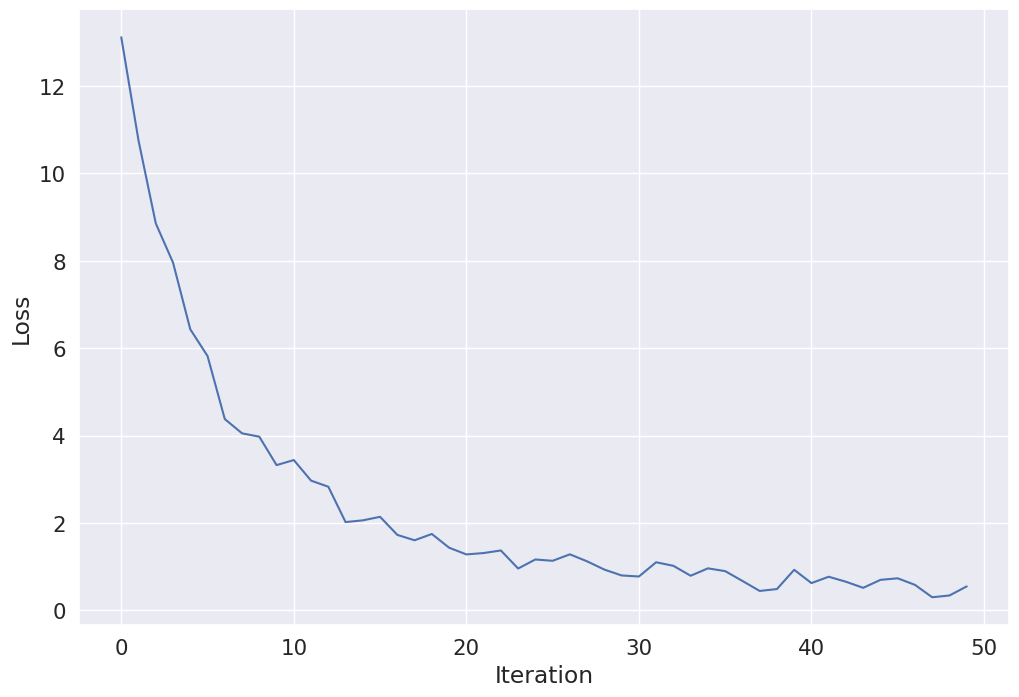

In [ ]:
plot_losses(losses2)

Check accuracy

In [ ]:
Y_train_pred2, Y_train_target2 = predict(train_dataloader_augmented, model2)
# calculate accuracy with balanced_accuracy_score function
accuracy = balanced_accuracy_score(Y_train_target2, Y_train_pred2)
print("Train accuracy:", accuracy)

Train accuracy: 0.9920625363501503


**Goal**: balanced_accuracy_score metric on the val part of the dataset is at least 0.96.

In [ ]:
Y_pred_val2, Y_target_val2 = predict(val_dataloader, model2)
accuracy = balanced_accuracy_score(Y_target_val2, Y_pred_val2)
print("val accuracy:", accuracy)
# calculate accuracy with balanced_accuracy_score function

val accuracy: 0.9479049405878675


The balanced accuracy score is less than 0.96 so I decreased the learning rate of the optimizer.

In [ ]:
model22 = SimpleCnn(256 , 1).to(device) #  create a new model with SimpleCnn class and move it to device
optimizer22 = torch.optim.Adam(model22.parameters(), lr=0.001)
loss_function = nn.BCEWithLogitsLoss()


In [ ]:
max_epochs = 50 
losses22 = train(model22 , optimizer22, loss_function, train_dataloader_augmented, max_epochs)

Epoch 0: loss=9.587635040283203
Epoch 1: loss=6.358340740203857
Epoch 2: loss=4.8207902908325195
Epoch 3: loss=4.082143306732178
Epoch 4: loss=3.5401828289031982
Epoch 5: loss=2.8788630962371826
Epoch 6: loss=2.32920241355896
Epoch 7: loss=1.9043552875518799
Epoch 8: loss=2.177541971206665
Epoch 9: loss=2.3429746627807617
Epoch 10: loss=1.8505204916000366
Epoch 11: loss=1.59469473361969
Epoch 12: loss=1.4681880474090576
Epoch 13: loss=1.2788102626800537
Epoch 14: loss=1.069946527481079
Epoch 15: loss=0.8803302049636841
Epoch 16: loss=0.9981324672698975
Epoch 17: loss=1.1352437734603882
Epoch 18: loss=1.3353643417358398
Epoch 19: loss=1.068593978881836
Epoch 20: loss=0.9821459054946899
Epoch 21: loss=0.6798917055130005
Epoch 22: loss=0.8270519971847534
Epoch 23: loss=0.8804179430007935
Epoch 24: loss=0.7751889228820801
Epoch 25: loss=0.7954002022743225
Epoch 26: loss=0.6233504414558411
Epoch 27: loss=0.4139224886894226
Epoch 28: loss=0.43860766291618347
Epoch 29: loss=0.6084085702896118

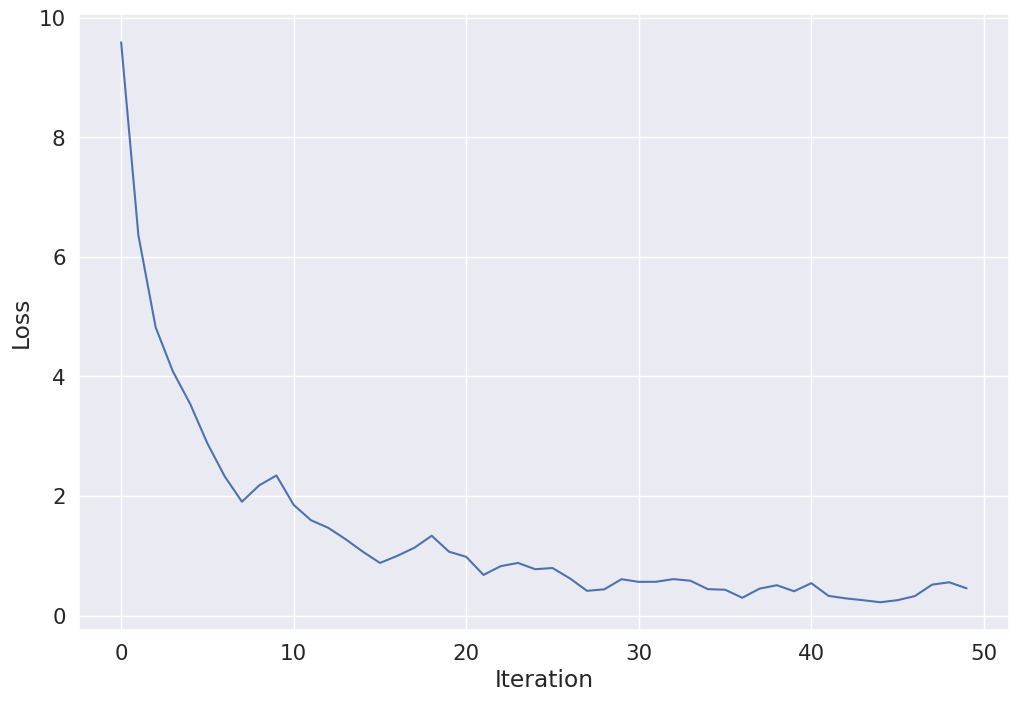

In [ ]:
plot_losses(losses22)

In [ ]:
Y_train_pred22, Y_train_target22 = predict(train_dataloader_augmented, model22)
# calculate accuracy with balanced_accuracy_score function
accuracy = balanced_accuracy_score(Y_train_target22, Y_train_pred22)
print("Train accuracy:", accuracy)

Train accuracy: 0.9964688179319963


In [ ]:
Y_pred_val22, Y_target_val22 = predict(val_dataloader, model22)
accuracy = balanced_accuracy_score(Y_target_val22, Y_pred_val22)
print("val accuracy:", accuracy)

val accuracy: 0.9627892432770482


## Transfer learning

The main idea is to load model and slightly tune it's parameters. The pre-trained models can be found in various libraries, for example in pytorch, or more specifically in [torchvision.models](https://pytorch.org/vision/stable/models.html#classification)

In [ ]:
model3 = models.alexnet(pretrained=True) # create model 
print(model3)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth
100%|██████████| 233M/233M [00:01<00:00, 169MB/s]


AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

First of all we must change the number of the outputs. For example, the models trained on IMAGENET have 1000 outputs, but we need only 1 output.

We can replace the whole classifier block (which is placed after convolution layers) or the last layer of the classifier.

In [ ]:
# Disable gradient calculations for the pretrained model
# It will speed up the calculations and it is a way for freeze parameters values
for par in model3.parameters():
  par.requires_grad = False

model3.classifier = nn.Sequential(
    nn.Linear(9216,4096),
    nn.ReLU(),
    nn.BatchNorm1d(4096),
    nn.Dropout(0.3),

    nn.Linear(4096 , 1000 ),
    nn.ReLU(),
    nn.BatchNorm1d(1000),
    nn.Dropout(0.3),

    nn.Linear(1000 , 1)
) 

In [ ]:
model3 = model3.to(device)

In [ ]:
# We can tune only classifier parameters by passing only that params to the optimizer
optimizer3 =  torch.optim.Adam(model3.classifier.parameters(), lr=0.001) #  create optimizer and pass to it onl ymodel3.classifier parameters
loss_function = nn.BCEWithLogitsLoss()


In [ ]:
max_epochs = 50
losses3 = train(model3 , optimizer3, loss_function, train_dataloader, max_epochs)

Epoch 0: loss=11.486781120300293
Epoch 1: loss=4.031103134155273
Epoch 2: loss=2.7964677810668945
Epoch 3: loss=1.8310078382492065
Epoch 4: loss=1.5233867168426514
Epoch 5: loss=1.2057521343231201
Epoch 6: loss=0.9276923537254333
Epoch 7: loss=1.0057324171066284
Epoch 8: loss=1.1738201379776
Epoch 9: loss=1.1905958652496338
Epoch 10: loss=0.9614837169647217
Epoch 11: loss=1.0060341358184814
Epoch 12: loss=0.8850167393684387
Epoch 13: loss=0.5231236219406128
Epoch 14: loss=0.7211622595787048
Epoch 15: loss=0.7317731976509094
Epoch 16: loss=0.7539066672325134
Epoch 17: loss=0.7403676509857178
Epoch 18: loss=0.5168905258178711
Epoch 19: loss=0.7748672366142273
Epoch 20: loss=0.7801580429077148
Epoch 21: loss=0.44792619347572327
Epoch 22: loss=0.2756260633468628
Epoch 23: loss=0.5079004168510437
Epoch 24: loss=0.4289432168006897
Epoch 25: loss=0.3054219186306
Epoch 26: loss=0.4786703884601593
Epoch 27: loss=0.429627388715744
Epoch 28: loss=0.4494054913520813
Epoch 29: loss=0.47464704513549

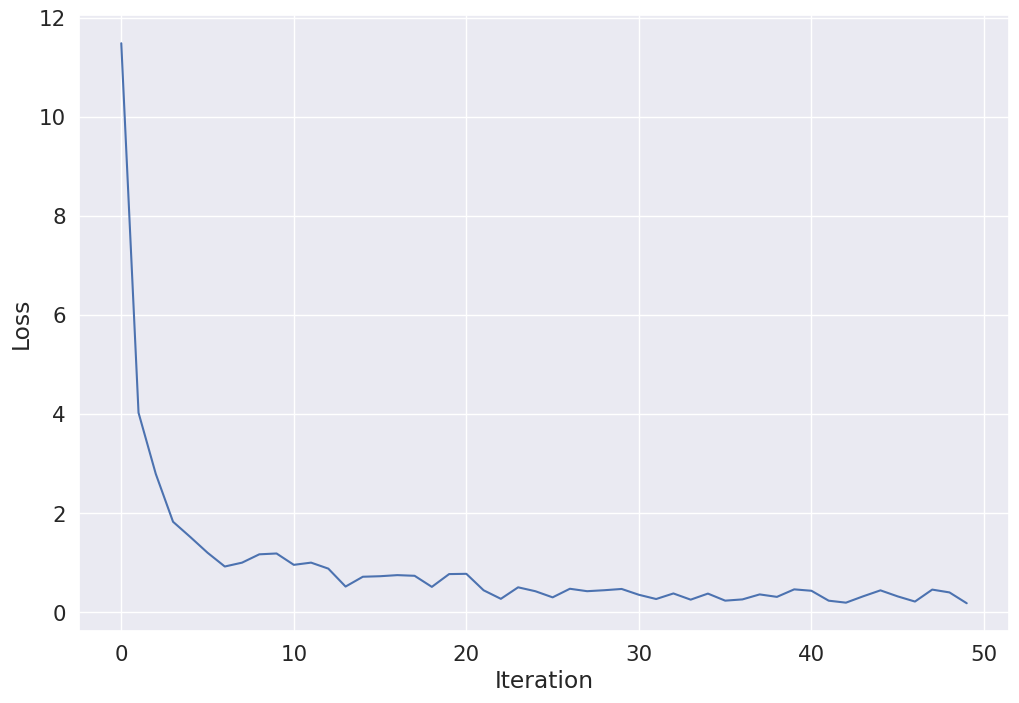

In [ ]:
plot_losses(losses3)

In [ ]:
Y_pred_train3, Y_train_target3 = predict(train_dataloader, model3)
# calculate accuracy with balanced_accuracy_score function
accuracy = balanced_accuracy_score(Y_train_target3, Y_pred_train3)
print("Train accuracy:", accuracy)

Train accuracy: 0.9962962962962962


**Goal**: balanced_accuracy_score metric on the val part of the dataset is at least **0.95**.

In [ ]:
Y_pred_val3, Y_target_val3 = predict(val_dataloader, model3)
# calculate accuracy with balanced_accuracy_score function
accuracy = balanced_accuracy_score(Y_target_val3, Y_pred_val3)
print("val accuracy:", accuracy)

val accuracy: 0.9503439649781114
